<a href="https://colab.research.google.com/github/Bensadon/Calculo-Numerico/blob/main/atividade3_david_bensadon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática III
## Métodos da Bisseção, de Newton e da Secante

**Aluno:** David Bensadon
**Disciplina:** Cálculo Numérico — UNIFESP
**Professora:** Raquel J. Lobosco

---

Neste notebook são implementados em Python os métodos da **bisseção**, de **Newton** e da **secante** para
encontrar raízes de funções, isto é, valores $r$ tais que $f(r) = 0$. Os métodos são aplicados às funções

$$
f_1(x) = x^2 - 2, \qquad f_2(x) = x^3 - x - 2, \qquad f_3(x) = e^{-x} - x, \qquad f_4(x) = x^3 - 2x + 2,
$$

os resultados são organizados em uma tabela e o processo de aproximação é ilustrado com animações exportadas em GIF.

**Organização:**
1. Configuração (tolerância, máximo de iterações, funções e casos de teste) — *é a única célula que precisa ser editada para testar outras funções ou valores iniciais*;
2. Parte 1 — implementação dos métodos;
3. Parte 2 — aplicação e tabela de resultados, com análise;
4. Parte 3 — animações gráficas (GIF).

In [ ]:
# ============================================================
# Bibliotecas
# ============================================================
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

## Configuração

Todos os parâmetros ficam concentrados aqui. Para testar outra função basta acrescentar uma entrada em `FUNCOES`
(expressão, derivada e rótulo); para testar outros valores iniciais basta acrescentar/alterar uma linha em `CASOS`.
Se a derivada não for informada (`None`), o método de Newton usa uma derivada numérica por diferença central.

In [ ]:
# ============================================================
# Parâmetros globais
# ============================================================
TOL = 1e-6        # tolerância usada nos critérios de parada
MAX_ITER = 100    # número máximo de iterações
EPS_ZERO = 1e-12  # abaixo disso uma derivada/denominador é considerado "zero"

# ============================================================
# Funções estudadas: nome -> (f, f', rótulo em LaTeX)
# ============================================================
FUNCOES = {
    "f1": (lambda x: x**2 - 2,
           lambda x: 2*x,
           r"$f_1(x) = x^2 - 2$"),
    "f2": (lambda x: x**3 - x - 2,
           lambda x: 3*x**2 - 1,
           r"$f_2(x) = x^3 - x - 2$"),
    "f3": (lambda x: np.exp(-x) - x,
           lambda x: -np.exp(-x) - 1,
           r"$f_3(x) = e^{-x} - x$"),
    "f4": (lambda x: x**3 - 2*x + 2,
           lambda x: 3*x**2 - 2,
           r"$f_4(x) = x^3 - 2x + 2$"),
}

# ============================================================
# Casos de teste: (função, método, valores iniciais)
#   bissecao -> (a, b)     newton -> (x0,)     secante -> (x0, x1)
# ============================================================
CASOS = [
    # --- valores sugeridos no enunciado ---
    ("f1", "bissecao", (1, 2)),   ("f1", "newton", (1.5,)), ("f1", "secante", (1, 2)),
    ("f2", "bissecao", (1, 2)),   ("f2", "newton", (1.5,)), ("f2", "secante", (1, 2)),
    ("f3", "bissecao", (0, 1)),   ("f3", "newton", (0.5,)), ("f3", "secante", (0, 1)),
    ("f4", "bissecao", (-2, -1)), ("f4", "newton", (-2,)),  ("f4", "secante", (-2, -1)),
    # --- valores escolhidos para testar as situações de falha (justificativa no texto) ---
    ("f1", "bissecao", (0, 1)),   # f(0)f(1) = (-2)(-1) > 0 -> não há troca de sinal
    ("f1", "newton",   (0,)),     # f1'(0) = 0 -> tangente horizontal
    ("f1", "secante",  (-1, 1)),  # f1(-1) = f1(1) -> denominador nulo
    ("f4", "newton",   (0,)),     # ciclo 0 -> 1 -> 0 -> 1 ... (não converge)
]

## Parte 1 — Implementação dos métodos

Cada método é uma função independente que devolve um dicionário com:

| chave | conteúdo |
|---|---|
| `raiz` | aproximação final da raiz |
| `iteracoes` | número de iterações realizadas |
| `aproximacoes` | lista com a aproximação calculada em cada iteração |
| `convergiu` | `True`/`False` |
| `mensagem` | motivo da parada (convergência ou tipo de falha) |
| `historico` | dados de cada passo (intervalos, tangentes, secantes) usados nas animações |

### Critério de parada adotado

Foram usados **os dois critérios ao mesmo tempo** (a iteração só é considerada convergida quando ambos são satisfeitos):

* **Newton e secante:** $\;|x_{k+1} - x_k| < \text{tol}\;$ **e** $\;|f(x_{k+1})| < \text{tol}$.
* **Bisseção:** o análogo de $|x_{k+1}-x_k|$ é a meia-largura do intervalo, que é um limitante do erro da raiz:
  $\;\dfrac{b_k - a_k}{2} < \text{tol}\;$ **e** $\;|f(c_k)| < \text{tol}$ (ou $f(c_k)=0$ exatamente).

**Justificativa:** usar só $|x_{k+1}-x_k|$ pode declarar convergência quando o método apenas "anda devagar" longe da raiz;
usar só $|f(x_{k+1})|$ pode enganar quando a função é muito achatada perto da raiz (resíduo pequeno com $x$ ainda longe).
Exigir as duas condições garante que a aproximação está estável **e** que de fato quase anula $f$.
O custo é, no máximo, uma iteração a mais — irrelevante para os métodos de Newton e secante, que convergem rapidamente.

### Detecção de falhas
* **Bisseção:** $f(a)f(b) > 0$ → não há garantia de raiz no intervalo; o método não inicia.
* **Newton:** $|f'(x_k)| < 10^{-12}$ → a tangente é (quase) horizontal e não corta o eixo $x$.
* **Secante:** $|f(x_k) - f(x_{k-1})| < 10^{-12}$ → a reta secante é (quase) horizontal.
* **Todos:** atingir `MAX_ITER` iterações sem satisfazer o critério de parada; também é tratado o caso de a iteração produzir valor não finito (overflow).

In [ ]:
def _resultado(raiz, aproximacoes, convergiu, mensagem, historico):
    # Empacota a saída dos métodos em um formato comum.
    return {"raiz": raiz, "iteracoes": len(aproximacoes), "aproximacoes": aproximacoes,
            "convergiu": convergiu, "mensagem": mensagem, "historico": historico}


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    # Método da bisseção no intervalo [a, b].
    fa, fb = f(a), f(b)
    if fa == 0:
        return _resultado(a, [], True, "f(a) = 0: a já é raiz", [])
    if fb == 0:
        return _resultado(b, [], True, "f(b) = 0: b já é raiz", [])
    if fa * fb > 0:
        return _resultado(None, [], False, "falha: f(a)·f(b) > 0 (sem troca de sinal em [a, b])", [])

    aproximacoes, historico = [], []
    for k in range(1, max_iter + 1):
        c = (a + b) / 2              # ponto médio = nova aproximação
        fc = f(c)
        aproximacoes.append(c)
        historico.append({"a": a, "b": b, "c": c})

        # critério de parada: meia-largura do intervalo E resíduo abaixo da tolerância
        if fc == 0 or ((b - a) / 2 < tol and abs(fc) < tol):
            return _resultado(c, aproximacoes, True, "convergiu", historico)

        # mantém a metade do intervalo onde há troca de sinal
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    return _resultado(c, aproximacoes, False, f"falha: não convergiu em {max_iter} iterações", historico)


def derivada_numerica(f, h=1e-6):
    # Derivada por diferença central, usada quando f' não é informada.
    return lambda x: (f(x + h) - f(x - h)) / (2 * h)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):
    # Método de Newton: x_{k+1} = x_k - f(x_k)/f'(x_k).
    if df is None:
        df = derivada_numerica(f)

    x = x0
    aproximacoes, historico = [], []
    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)
        if abs(dfx) < EPS_ZERO:
            return _resultado(x, aproximacoes, False,
                              f"falha: f'(x) ≈ 0 em x = {x:.6g} (tangente horizontal)", historico)

        x_novo = x - fx / dfx        # raiz da reta tangente em (x, f(x))
        if not math.isfinite(x_novo):
            return _resultado(x, aproximacoes, False, "falha: iteração divergiu (valor não finito)", historico)

        aproximacoes.append(x_novo)
        historico.append({"x": x, "fx": fx, "dfx": dfx, "x_novo": x_novo})

        # critério de parada: passo E resíduo abaixo da tolerância
        if abs(x_novo - x) < tol and abs(f(x_novo)) < tol:
            return _resultado(x_novo, aproximacoes, True, "convergiu", historico)
        x = x_novo

    return _resultado(x, aproximacoes, False, f"falha: não convergiu em {max_iter} iterações", historico)


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    # Método da secante: x_{k+1} = x_k - f(x_k)(x_k - x_{k-1}) / (f(x_k) - f(x_{k-1})).
    x_ant, x = x0, x1
    f_ant, fx = f(x_ant), f(x)
    aproximacoes, historico = [], []
    for k in range(1, max_iter + 1):
        denom = fx - f_ant
        if abs(denom) < EPS_ZERO:
            return _resultado(x, aproximacoes, False,
                              "falha: f(x_k) - f(x_{k-1}) ≈ 0 (secante horizontal)", historico)

        x_novo = x - fx * (x - x_ant) / denom   # raiz da reta pelos dois últimos pontos
        if not math.isfinite(x_novo):
            return _resultado(x, aproximacoes, False, "falha: iteração divergiu (valor não finito)", historico)

        aproximacoes.append(x_novo)
        historico.append({"x_ant": x_ant, "f_ant": f_ant, "x": x, "fx": fx, "x_novo": x_novo})

        f_novo = f(x_novo)
        # critério de parada: passo E resíduo abaixo da tolerância
        if abs(x_novo - x) < tol and abs(f_novo) < tol:
            return _resultado(x_novo, aproximacoes, True, "convergiu", historico)
        x_ant, f_ant, x, fx = x, fx, x_novo, f_novo

    return _resultado(x, aproximacoes, False, f"falha: não convergiu em {max_iter} iterações", historico)

In [ ]:
def resolver(nome_f, metodo, iniciais, tol=TOL, max_iter=MAX_ITER):
    # Aplica o método escolhido à função `nome_f` com os valores iniciais dados.
    f, df, _ = FUNCOES[nome_f]
    if metodo == "bissecao":
        return bissecao(f, *iniciais, tol=tol, max_iter=max_iter)
    if metodo == "newton":
        return newton(f, df, *iniciais, tol=tol, max_iter=max_iter)
    if metodo == "secante":
        return secante(f, *iniciais, tol=tol, max_iter=max_iter)
    raise ValueError(f"método desconhecido: {metodo}")


def tabela_iteracoes(nome_f, metodo, iniciais):
    # Tabela passo a passo: iteração, aproximação, resíduo e diferença entre aproximações.
    f = FUNCOES[nome_f][0]
    res = resolver(nome_f, metodo, iniciais)
    xs = res["aproximacoes"]
    linhas = []
    for k, x in enumerate(xs, start=1):
        dif = abs(x - xs[k-2]) if k > 1 else float("nan")
        linhas.append({"k": k, "x_k": f"{x:.10f}", "|f(x_k)|": f"{abs(f(x)):.3e}",
                       "|x_k - x_(k-1)|": f"{dif:.3e}"})
    print(f"{nome_f} — {metodo} — valores iniciais {iniciais}: {res['mensagem']}")
    display(pd.DataFrame(linhas).set_index("k"))

### Teste rápido das implementações

Evolução das iterações para $f_2$ com os três métodos (valores sugeridos):

In [ ]:
tabela_iteracoes("f2", "bissecao", (1, 2))
tabela_iteracoes("f2", "newton", (1.5,))
tabela_iteracoes("f2", "secante", (1, 2))

f2 — bissecao — valores iniciais (1, 2): convergiu


,x_k,|f(x_k)|,|x_k - x_(k-1)|
k,,,
1,1.5000000000,1.250e-01,nan
2,1.7500000000,1.609e+00,2.500e-01
3,1.6250000000,6.660e-01,1.250e-01
4,1.5625000000,2.522e-01,6.250e-02
5,1.5312500000,5.911e-02,3.125e-02
6,1.5156250000,3.405e-02,1.562e-02
7,1.5234375000,1.225e-02,7.812e-03
8,1.5195312500,1.097e-02,3.906e-03
9,1.5214843750,6.222e-04,1.953e-03


f2 — newton — valores iniciais (1.5,): convergiu


,x_k,|f(x_k)|,|x_k - x_(k-1)|
k,,,
1,1.5217391304,2.137e-03,nan
2,1.5213798060,5.894e-07,3.593e-04
3,1.5213797068,4.530e-14,9.916e-08


f2 — secante — valores iniciais (1, 2): convergiu


,x_k,|f(x_k)|,|x_k - x_(k-1)|
k,,,
1,1.3333333333,9.630e-01,nan
2,1.4626865672,3.333e-01,1.294e-01
3,1.5311694321,5.863e-02,6.848e-02
4,1.5209264205,2.693e-03,1.024e-02
5,1.5213763167,2.015e-05,4.499e-04
6,1.5213797080,7.015e-09,3.391e-06
7,1.5213797068,1.843e-14,1.180e-09


## Parte 2 — Aplicação e análise

Todos os casos da lista `CASOS` são executados e resumidos na tabela abaixo.

Além dos valores sugeridos no enunciado, foram incluídos **quatro casos escolhidos de propósito para provocar falhas**,
de modo a verificar se o código as detecta corretamente:

* **$f_1$, bisseção em $[0, 1]$:** $f_1(0) = -2$ e $f_1(1) = -1$ têm o mesmo sinal, logo $f(a)f(b) > 0$.
* **$f_1$, Newton com $x_0 = 0$:** $f_1'(0) = 0$, a tangente é horizontal.
* **$f_1$, secante com $(x_0, x_1) = (-1, 1)$:** $f_1(-1) = f_1(1) = -1$, o denominador é nulo.
* **$f_4$, Newton com $x_0 = 0$:** exemplo clássico de ciclo — $x_1 = 0 - \frac{2}{-2} = 1$ e $x_2 = 1 - \frac{1}{1} = 0$,
  então a sequência oscila $0, 1, 0, 1, \dots$ e não converge em 100 iterações.

In [ ]:
NOMES_METODOS = {"bissecao": "Bisseção", "newton": "Newton", "secante": "Secante"}

def rotulo_texto(rotulo):
    # Converte o rótulo LaTeX em texto simples para a tabela (ex.: "f3(x) = e^(-x) - x").
    t = re.sub(r"_(\d)", r"\1", rotulo.strip("$"))
    return t.replace("{", "(").replace("}", ")")

def fmt_iniciais(metodo, iniciais):
    if metodo == "bissecao":
        return f"[a, b] = [{iniciais[0]}, {iniciais[1]}]"
    if metodo == "newton":
        return f"x0 = {iniciais[0]}"
    return f"(x0, x1) = ({iniciais[0]}, {iniciais[1]})"

linhas = []
RESULTADOS = {}
for nome_f, metodo, iniciais in CASOS:
    res = resolver(nome_f, metodo, iniciais)
    RESULTADOS[(nome_f, metodo, iniciais)] = res
    f, _, rotulo = FUNCOES[nome_f]
    raiz = res["raiz"]
    if res["convergiu"]:
        situacao = f"{res['iteracoes']} iterações — convergiu"
    else:
        situacao = f"{res['iteracoes']} iterações — {res['mensagem']}"
    linhas.append({
        "Função": rotulo_texto(rotulo),
        "Método": NOMES_METODOS[metodo],
        "Valores iniciais": fmt_iniciais(metodo, iniciais),
        "Raiz aproximada": "—" if raiz is None or not res["convergiu"] else f"{raiz:.10f}",
        "|f(x)| final": "—" if raiz is None else f"{abs(f(raiz)):.3e}",
        "Iterações/resultado": situacao,
    })

tabela = pd.DataFrame(linhas)
display(tabela)

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x^2 - 2,Bisseção,"[a, b] = [1, 2]",1.4142136574,2.687e-07,21 iterações — convergiu
1,f1(x) = x^2 - 2,Newton,x0 = 1.5,1.4142135624,4.441e-16,4 iterações — convergiu
2,f1(x) = x^2 - 2,Secante,"(x0, x1) = (1, 2)",1.4142135624,8.882e-16,6 iterações — convergiu
3,f2(x) = x^3 - x - 2,Bisseção,"[a, b] = [1, 2]",1.5213797092,1.450e-08,22 iterações — convergiu
4,f2(x) = x^3 - x - 2,Newton,x0 = 1.5,1.5213797068,4.530e-14,3 iterações — convergiu
5,f2(x) = x^3 - x - 2,Secante,"(x0, x1) = (1, 2)",1.5213797068,1.843e-14,7 iterações — convergiu
6,f3(x) = e^(-x) - x,Bisseção,"[a, b] = [0, 1]",0.5671434402,2.348e-07,20 iterações — convergiu
7,f3(x) = e^(-x) - x,Newton,x0 = 0.5,0.5671432904,4.441e-15,3 iterações — convergiu
8,f3(x) = e^(-x) - x,Secante,"(x0, x1) = (0, 1)",0.5671432904,1.242e-13,5 iterações — convergiu
9,f4(x) = x^3 - 2x + 2,Bisseção,"[a, b] = [-2, -1]",-1.7692923546,2.551e-09,21 iterações — convergiu


Tabela resumida apenas com os valores sugeridos no enunciado, lado a lado, para comparar o número de iterações:

In [ ]:
comparacao = (tabela.iloc[:12]
              .assign(Iterações=[RESULTADOS[c]["iteracoes"] for c in CASOS[:12]])
              .pivot(index="Função", columns="Método", values="Iterações")
              [["Bisseção", "Newton", "Secante"]])
display(comparacao)

# Conferência com valores de referência (raízes reais obtidas por numpy.roots / valor exato)
referencia = {
    "f1": math.sqrt(2),
    "f2": np.roots([1, 0, -1, -2]).real[np.abs(np.roots([1, 0, -1, -2]).imag) < 1e-12][0],
    "f3": 0.5671432904097838,   # constante ômega: raiz de e^{-x} = x
    "f4": np.roots([1, 0, -2, 2]).real[np.abs(np.roots([1, 0, -2, 2]).imag) < 1e-12][0],
}
for (nome_f, metodo, iniciais) in CASOS[:12]:
    r = RESULTADOS[(nome_f, metodo, iniciais)]["raiz"]
    print(f"{nome_f} {NOMES_METODOS[metodo]:9s} erro |x - r| = {abs(r - referencia[nome_f]):.2e}")

Método,Bisseção,Newton,Secante
Função,,,
f1(x) = x^2 - 2,21,4,6
f2(x) = x^3 - x - 2,22,3,7
f3(x) = e^(-x) - x,20,3,5
f4(x) = x^3 - 2x + 2,21,4,7


f1 Bisseção  erro |x - r| = 9.50e-08
f1 Newton    erro |x - r| = 0.00e+00
f1 Secante   erro |x - r| = 2.22e-16
f2 Bisseção  erro |x - r| = 2.44e-09
f2 Newton    erro |x - r| = 6.88e-15
f2 Secante   erro |x - r| = 3.77e-15
f3 Bisseção  erro |x - r| = 1.50e-07
f3 Newton    erro |x - r| = 2.78e-15
f3 Secante   erro |x - r| = 7.93e-14
f4 Bisseção  erro |x - r| = 3.45e-10
f4 Newton    erro |x - r| = 6.86e-14
f4 Secante   erro |x - r| = 2.21e-12


In [ ]:
# Salva a tabela de resultados em CSV (para anexar ao dashboard)
tabela.to_csv("tabela_resultados.csv", index=False)
print("tabela_resultados.csv salvo.")

tabela_resultados.csv salvo.


### Análise dos resultados

**Todos os métodos encontraram as raízes com os valores sugeridos**, e as aproximações coincidem com os valores de referência
($\sqrt{2} \approx 1{,}4142135624$; $r_2 \approx 1{,}5213797068$; $r_3 \approx 0{,}5671432904$; $r_4 \approx -1{,}7692923542$).

| Função | Bisseção | Newton | Secante |
|---|---|---|---|
| $f_1$ | 21 | 4 | 6 |
| $f_2$ | 22 | 3 | 7 |
| $f_3$ | 20 | 3 | 5 |
| $f_4$ | 21 | 4 | 7 |

**Bisseção.** Precisou de 20 a 22 iterações em todos os casos. Isso é esperado: o intervalo é dividido por 2 a cada passo,
então, com largura inicial 1, são necessárias cerca de $\log_2(1/10^{-6}) \approx 20$ iterações para a meia-largura ficar
abaixo de $10^{-6}$, **independentemente da função**. A convergência é linear e lenta, mas **garantida** sempre que $f$ é
contínua e $f(a)f(b) < 0$. O erro final ficou na ordem de $10^{-7}$ a $10^{-10}$ — coerente com a tolerância.
Na tabela passo a passo de $f_2$ nota-se também que o resíduo **não decresce de forma monótona** (ele oscila), porque a
bisseção só usa o sinal de $f$, não seu valor.

**Newton.** Foi o mais rápido: 3 ou 4 iterações. A convergência é quadrática — o número de casas corretas praticamente dobra a
cada passo (em $f_2$: resíduos $2\cdot10^{-3} \to 6\cdot10^{-7} \to 5\cdot10^{-14}$). O preço é precisar da derivada $f'(x)$ e de um
$x_0$ suficientemente próximo da raiz. Os erros finais ficaram na ordem de $10^{-14}$ a $10^{-16}$ (precisão de máquina).

**Secante.** Ficou entre os dois: 5 a 7 iterações. Sua convergência é superlinear (ordem $\approx 1{,}618$), um pouco mais lenta
que Newton, mas **não exige a derivada** — ela é aproximada pela inclinação da reta que passa pelos dois últimos pontos.
Cada iteração custa apenas uma nova avaliação de $f$, enquanto Newton avalia $f$ e $f'$.

**Casos de falha (dependência dos valores iniciais).** Os quatro testes adicionais mostram que o código detecta corretamente
as situações em que não é possível continuar:

* $f_1$ em $[0, 1]$: a bisseção nem começa, pois $f(0)f(1) > 0$ (a raiz $\sqrt2$ está fora do intervalo);
* $f_1$ com $x_0 = 0$: Newton para imediatamente, pois $f_1'(0) = 0$;
* $f_1$ com $(-1, 1)$: a secante para, pois $f_1(-1) = f_1(1)$ e a reta é horizontal — os pontos são simétricos em relação ao vértice da parábola;
* $f_4$ com $x_0 = 0$: Newton entra no ciclo $0 \to 1 \to 0 \to \dots$ e esgota as 100 iterações sem convergir. Já com $x_0 = -2$
  (valor sugerido) o mesmo método converge em 4 iterações. Isso mostra que **Newton é muito sensível ao chute inicial**:
  $f_4$ tem um mínimo local em $x \approx 0{,}816$ acima do eixo, e partindo de perto dele as tangentes "jogam" a iteração de
  um lado para o outro sem nunca se aproximar da raiz real, que está em $x \approx -1{,}769$.

**Conclusão.** A bisseção é robusta, porém lenta; Newton é o mais rápido, mas depende da derivada e de um bom chute inicial;
a secante é um bom meio-termo quando a derivada é difícil de obter. Uma estratégia prática é usar algumas iterações de
bisseção para localizar a raiz e depois refinar com Newton ou secante.

## Parte 3 — Animações gráficas

A função `animar` gera uma animação para qualquer combinação (função, método, valores iniciais) e a exporta em GIF.
Cada quadro mostra:

* o gráfico de $f(x)$ e o eixo $y = 0$;
* os pontos das aproximações já produzidas (mais claros) e a aproximação atual;
* **bisseção:** o intervalo $[a_k, b_k]$ sombreado, que é reduzido à metade a cada iteração;
* **Newton:** a reta tangente em $(x_k, f(x_k))$ e sua interseção com o eixo $x$;
* **secante:** a reta que passa por $(x_{k-1}, f(x_{k-1}))$ e $(x_k, f(x_k))$ e sua interseção com o eixo $x$;
* o número da iteração, o valor atual da aproximação e o resíduo $|f(x_k)|$.

Os métodos de Newton e secante convergem em poucas iterações e os passos finais ficam invisíveis na escala do gráfico;
por isso, a partir de certo ponto a janela é **ampliada (zoom) em torno da aproximação atual**, o que permite
continuar enxergando as retas.

In [ ]:
def _janela(xs, margem=0.25, largura_min=1e-3):
    # Limites [x_min, x_max] com margem em torno dos pontos dados.
    lo, hi = min(xs), max(xs)
    if hi - lo < largura_min:
        meio = (lo + hi) / 2
        lo, hi = meio - largura_min / 2, meio + largura_min / 2
    d = hi - lo
    return lo - margem * d, hi + margem * d


def animar(nome_f, metodo, iniciais, arquivo=None, max_quadros=25, intervalo_ms=1200, zoom=True):
    # Gera a animação do método e salva em GIF. Retorna o nome do arquivo.
    f, _, rotulo = FUNCOES[nome_f]
    res = resolver(nome_f, metodo, iniciais)
    hist = res["historico"][:max_quadros]
    if not hist:
        raise ValueError(f"nada para animar: {res['mensagem']}")
    arquivo = arquivo or f"{nome_f}_{metodo}.gif"

    # janela global com todos os pontos relevantes do processo
    pts = list(iniciais) + [x for x in res["aproximacoes"][:max_quadros]]
    x_lo, x_hi = _janela(pts, largura_min=1.0)

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.subplots_adjust(left=0.08, right=0.70)

    def desenha(k):
        ax.clear()
        passo = hist[k]
        x_atual = res["aproximacoes"][k]

        # janela: global nos primeiros quadros, depois zoom em torno do passo atual
        if metodo == "bissecao":
            lo, hi = (x_lo, x_hi) if (not zoom or k < 6) else _janela([passo["a"], passo["b"]], 0.6)
        elif metodo == "newton":
            lo, hi = (x_lo, x_hi) if (not zoom or k < 2) else _janela([passo["x"], passo["x_novo"]], 1.0)
        else:
            lo, hi = (x_lo, x_hi) if (not zoom or k < 2) else _janela([passo["x_ant"], passo["x"], passo["x_novo"]], 0.6)

        xx = np.linspace(lo, hi, 600)
        yy = f(xx)
        ax.plot(xx, yy, color="tab:blue", lw=2, label=rotulo)
        ax.axhline(0, color="black", lw=0.8)

        if metodo == "bissecao":
            a, b, c = passo["a"], passo["b"], passo["c"]
            ax.axvspan(a, b, color="tab:orange", alpha=0.18, label=f"intervalo [a, b]")
            ax.plot([a, b], [f(a), f(b)], "o", color="tab:orange", ms=7)
            ax.vlines([a, b], 0, [f(a), f(b)], colors="tab:orange", linestyles=":")
            ax.plot([c], [0], "o", color="tab:red", ms=8, label="ponto médio c")
            ax.plot([c], [f(c)], "x", color="tab:red", ms=8)
            ax.vlines(c, 0, f(c), colors="tab:red", linestyles="--")
            info = f"a = {a:.8f}\nb = {b:.8f}\nlargura = {b - a:.2e}"

        elif metodo == "newton":
            x, fx, dfx, xn = passo["x"], passo["fx"], passo["dfx"], passo["x_novo"]
            ax.plot(xx, fx + dfx * (xx - x), color="tab:green", lw=1.5, label="reta tangente")
            ax.plot([x], [fx], "o", color="tab:green", ms=7)
            ax.vlines(x, 0, fx, colors="gray", linestyles=":")
            ax.plot([xn], [0], "o", color="tab:red", ms=8, label="$x_{k+1}$")
            info = f"$x_k$ = {x:.8f}\n$f'(x_k)$ = {dfx:.4f}"

        else:
            x0, f0, x1, f1, xn = passo["x_ant"], passo["f_ant"], passo["x"], passo["fx"], passo["x_novo"]
            incl = (f1 - f0) / (x1 - x0)
            ax.plot(xx, f1 + incl * (xx - x1), color="tab:purple", lw=1.5, label="reta secante")
            ax.plot([x0, x1], [f0, f1], "o", color="tab:purple", ms=7)
            ax.vlines([x0, x1], 0, [f0, f1], colors="gray", linestyles=":")
            ax.plot([xn], [0], "o", color="tab:red", ms=8, label="$x_{k+1}$")
            info = f"$x_{{k-1}}$ = {x0:.8f}\n$x_k$ = {x1:.8f}"

        # aproximações anteriores (mais claras)
        anteriores = [p for p in res["aproximacoes"][:k] if lo <= p <= hi]
        ax.plot(anteriores, np.zeros(len(anteriores)), "o", color="tab:red", alpha=0.25, ms=6)

        ax.set_xlim(lo, hi)
        ymin, ymax = min(np.min(yy), 0), max(np.max(yy), 0)   # garante que y = 0 aparece
        dy = max(ymax - ymin, 1e-9)
        ax.set_ylim(ymin - 0.15 * dy, ymax + 0.15 * dy)
        ax.grid(alpha=0.3)
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.set_title(f"{NOMES_METODOS[metodo]} — {rotulo} — iteração {k + 1}")
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
        texto = (f"iteração: {k + 1}\naproximação: {x_atual:.10f}\n"
                 f"resíduo |f(x)|: {abs(f(x_atual)):.2e}\n{info}")
        ax.text(1.03, 0.5, texto, transform=ax.transAxes, ha="left", va="center", fontsize=9,
                family="monospace", bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

    anim = FuncAnimation(fig, desenha, frames=len(hist), interval=intervalo_ms)
    anim.save(arquivo, writer=PillowWriter(fps=1000 / intervalo_ms))
    plt.close(fig)
    print(f"{arquivo} salvo ({len(hist)} quadros) — {res['mensagem']}")
    return arquivo

### Animações escolhidas

1. **Bisseção** em $f_1(x) = x^2 - 2$, intervalo $[1, 2]$ (primeiros 25 passos — os demais têm largura invisível);
2. **Newton** em $f_2(x) = x^3 - x - 2$, $x_0 = 1{,}5$;
3. **Secante** em $f_3(x) = e^{-x} - x$, $(x_0, x_1) = (0, 1)$;
4. *(extra)* **Newton** em $f_4(x) = x^3 - 2x + 2$ com $x_0 = 0$ — mostra o ciclo $0 \to 1 \to 0 \to \dots$ (falha), sem zoom.

In [ ]:
gifs = [
    animar("f1", "bissecao", (1, 2)),
    animar("f2", "newton", (1.5,)),
    animar("f3", "secante", (0, 1)),
    animar("f4", "newton", (0,), arquivo="f4_newton_ciclo.gif", max_quadros=6, zoom=False),
]

f1_bissecao.gif salvo (21 quadros) — convergiu


f2_newton.gif salvo (3 quadros) — convergiu


f3_secante.gif salvo (5 quadros) — convergiu


f4_newton_ciclo.gif salvo (6 quadros) — falha: não convergiu em 100 iterações


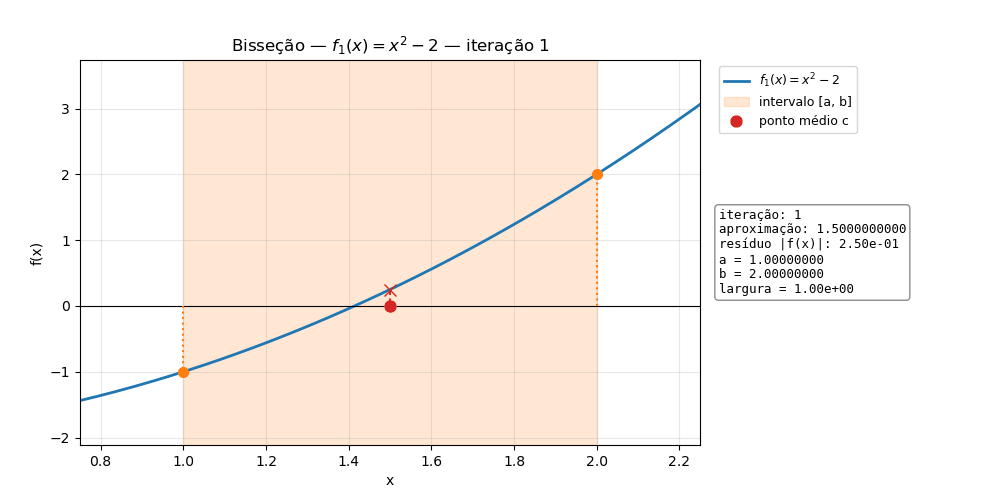

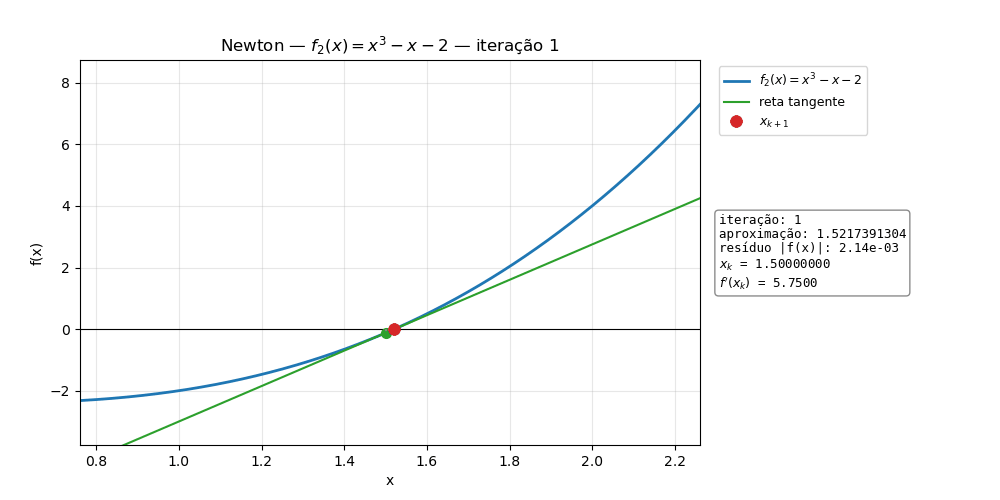

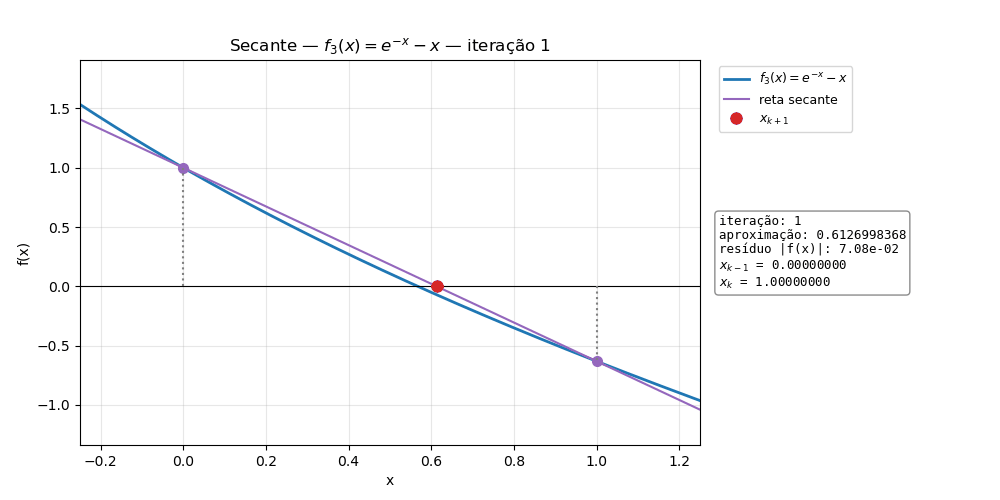

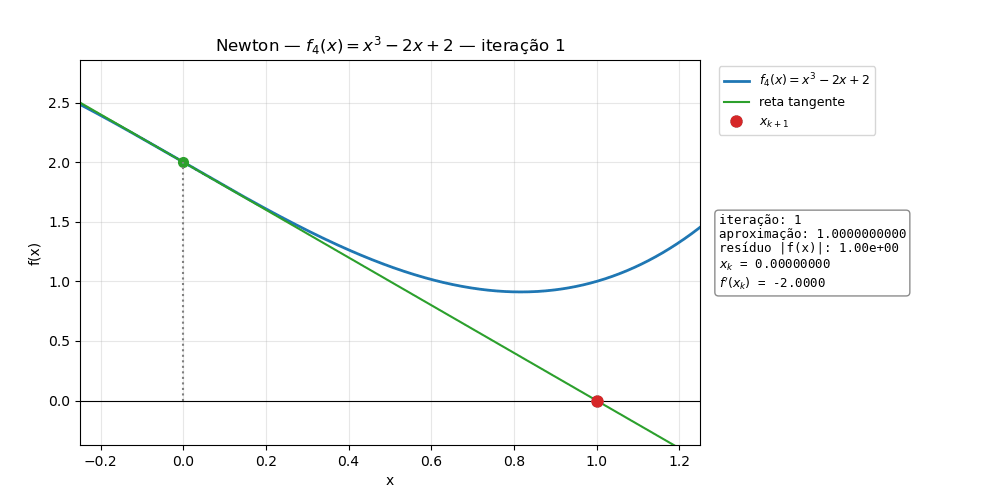

In [ ]:
for g in gifs:
    display(Image(filename=g))

### Download dos arquivos

No Google Colab, a célula abaixo baixa os GIFs e a tabela em CSV para anexar ao dashboard do Mathcha.
(Os arquivos também aparecem no painel de arquivos à esquerda do Colab.)

In [ ]:
try:
    from google.colab import files
    for arq in gifs + ["tabela_resultados.csv"]:
        files.download(arq)
except ImportError:
    print("Fora do Colab: os arquivos foram salvos na pasta atual:", gifs + ["tabela_resultados.csv"])

Fora do Colab: os arquivos foram salvos na pasta atual: ['f1_bissecao.gif', 'f2_newton.gif', 'f3_secante.gif', 'f4_newton_ciclo.gif', 'tabela_resultados.csv']
